In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [57]:
data = pd.read_csv("spotify_songs.csv")
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns")
data.dtypes

The dataset has 32833 rows and 23 columns


track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [58]:
data.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [59]:
data.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [60]:
data.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [61]:
data[data.duplicated("track_id")]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
1299,1HfMVBKM75vxSfsQ5VefZ5,Lose You To Love Me,Selena Gomez,93,3tBkjgxDqAwss76O1YHsSY,Lose You To Love Me,2019-10-23,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,46Cl6dmeiylK6TRGXr7hHe,pop,...,4,-9.005,1,0.0438,0.576000,0.00000,0.2100,0.0916,101.993,206459
1300,2b8fOow8UzyDFAE27YhOZM,Memories,Maroon 5,98,3nR9B40hYLKLcR0Eph3Goc,Memories,2019-09-20,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,46Cl6dmeiylK6TRGXr7hHe,pop,...,11,-7.209,1,0.0546,0.837000,0.00000,0.0822,0.5750,91.019,189486
1304,7qEHsqek33rTcFNT9PFqLf,Someone You Loved,Lewis Capaldi,94,5658aM19fA3JVwTK6eQX70,Divinely Uninspired To A Hellish Extent,2019-05-17,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,46Cl6dmeiylK6TRGXr7hHe,pop,...,1,-5.679,1,0.0319,0.751000,0.00000,0.1050,0.4460,109.891,182161
1305,6v3KW9xbzN5yKLt9YKDYA2,Señorita,Shawn Mendes,88,0xzScN8P3hQAz3BT3YYX5w,Shawn Mendes (Deluxe),2019-06-19,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,46Cl6dmeiylK6TRGXr7hHe,pop,...,9,-6.049,0,0.0290,0.039200,0.00000,0.0828,0.7490,116.967,190800
1307,6cy3ki60hLwimwIje7tALf,RITMO (Bad Boys For Life),The Black Eyed Peas,96,6EobpC5SDFy5DF50dWNVGF,RITMO (Bad Boys For Life),2019-10-12,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,46Cl6dmeiylK6TRGXr7hHe,pop,...,10,-7.037,0,0.0657,0.033400,0.00084,0.2370,0.6670,104.994,221714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32783,1mzGywacjpeik00PVLBPpF,All of Me (Tiësto's Birthday Treatment Remix) ...,John Legend,64,4c2rSdHI9WUXn0zyXoWtbB,All of Me (Tiësto's Birthday Treatment Remix) ...,2014-02-25,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,5,-6.253,0,0.0283,0.000151,0.00165,0.0745,0.1790,127.986,251613
32793,1nas007nDbzLwDGwvMdz79,How You Love Me,3LAU,52,0IsgaoqRfJAJ6wojxWDZ7C,How You Love Me,2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,1,-3.648,1,0.0839,0.183000,0.00000,0.3400,0.2860,127.961,210469
32798,65hRZOQkVjmBdusz1N7aOv,Save The World,Swedish House Mafia,67,728voOLBbJUBgK2vooghcS,Save The World,2011-05-13,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-7.598,1,0.0474,0.014400,0.00000,0.0759,0.4000,126.879,213338
32804,2KlZexJjJPuNWcN5uAG1GU,Gold (feat. Yuna),Adventure Club,1,2DVyzKYzqlQo4uTJLVtvBt,Calling All Heroes - EP,2013-10-22,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,9,-4.893,0,0.0413,0.031900,0.00536,0.1280,0.1890,145.022,257045


In [62]:
data = data.dropna(subset=['track_name', 'track_artist', 'track_album_name'])


In [63]:
data = data.drop_duplicates(subset='track_id', keep='first')
data

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [64]:

def normalize_date(d):
    if pd.isna(d):
        return d
    parts = str(d).split('-')
    if len(parts) == 1:
        return f"{parts[0]}-01-01"   # year only
    elif len(parts) == 2:
        return f"{parts[0]}-{parts[1]}-01"  # year-month
    return d  # already full
data['track_album_release_date'] = (data['track_album_release_date'].apply(normalize_date).pipe(pd.to_datetime, format='%Y-%m-%d'))

data['release_year']  = data['track_album_release_date'].dt.year
data['release_month'] = data['track_album_release_date'].dt.month

In [65]:
data['Duration']=data['duration_ms']/60000

In [66]:
data.sort_values(by=['playlist_genre', 'playlist_subgenre'], inplace=True)
data.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year,release_month,Duration
28301,37FfCz1YODL6NAuWfxUzJh,Left Right,Hardwell,58,3192TqWaoGyc53bEHlcl45,Left Right,2019-10-18,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,0.0666,0.000373,0.353,0.2850,0.192,128.005,155827,2019,10,2.597117
28305,29C3wkt3HoxHtEalb0mUWP,I'm In Love,NDR8,34,4FeSeO5vSj5W7dFajS0osc,I'm In Love,2020-01-10,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,0.0841,0.002160,0.642,0.0788,0.450,126.048,140615,2020,1,2.343583
28306,1ov2kWVkqFTFEcpgRXnphS,Future Noise,KAAZE,47,0OqmUVeJRWIKD1PHJRjcZd,Future Noise,2019-12-25,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,0.0683,0.004040,0.888,0.4400,0.415,128.015,203906,2019,12,3.398433
28308,14BmGOdWFMkxiyQ7f4s03L,Here With Me (feat. Nevve),ARMNHMR,38,4cBVizWVamVwH4v5g6zTto,Here With Me (feat. Nevve),2020-01-17,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,0.0406,0.120000,0.000,0.2740,0.346,145.024,205241,2020,1,3.420683
28309,2fxnEwR9xa48aknKlcpKyZ,Milk Man 2019,KAAZE,45,1ZCEGV103vCR1T15MszF5w,Milk Man 2019,2019-12-13,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,0.0565,0.000855,0.947,0.3190,0.533,128.014,170684,2019,12,2.844733


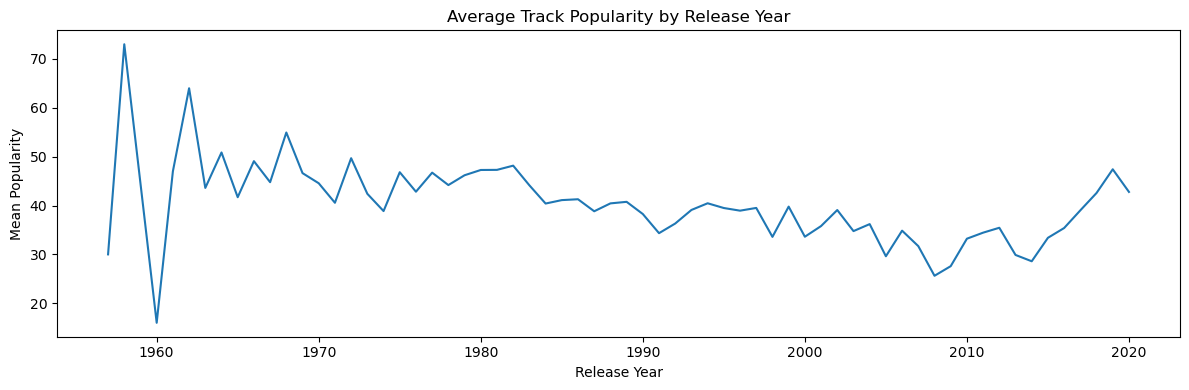

In [67]:
yearly = (
    data.groupby('release_year')['track_popularity']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=yearly, x='release_year', y='track_popularity')
plt.title('Average Track Popularity by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Mean Popularity')
plt.tight_layout()
plt.show()

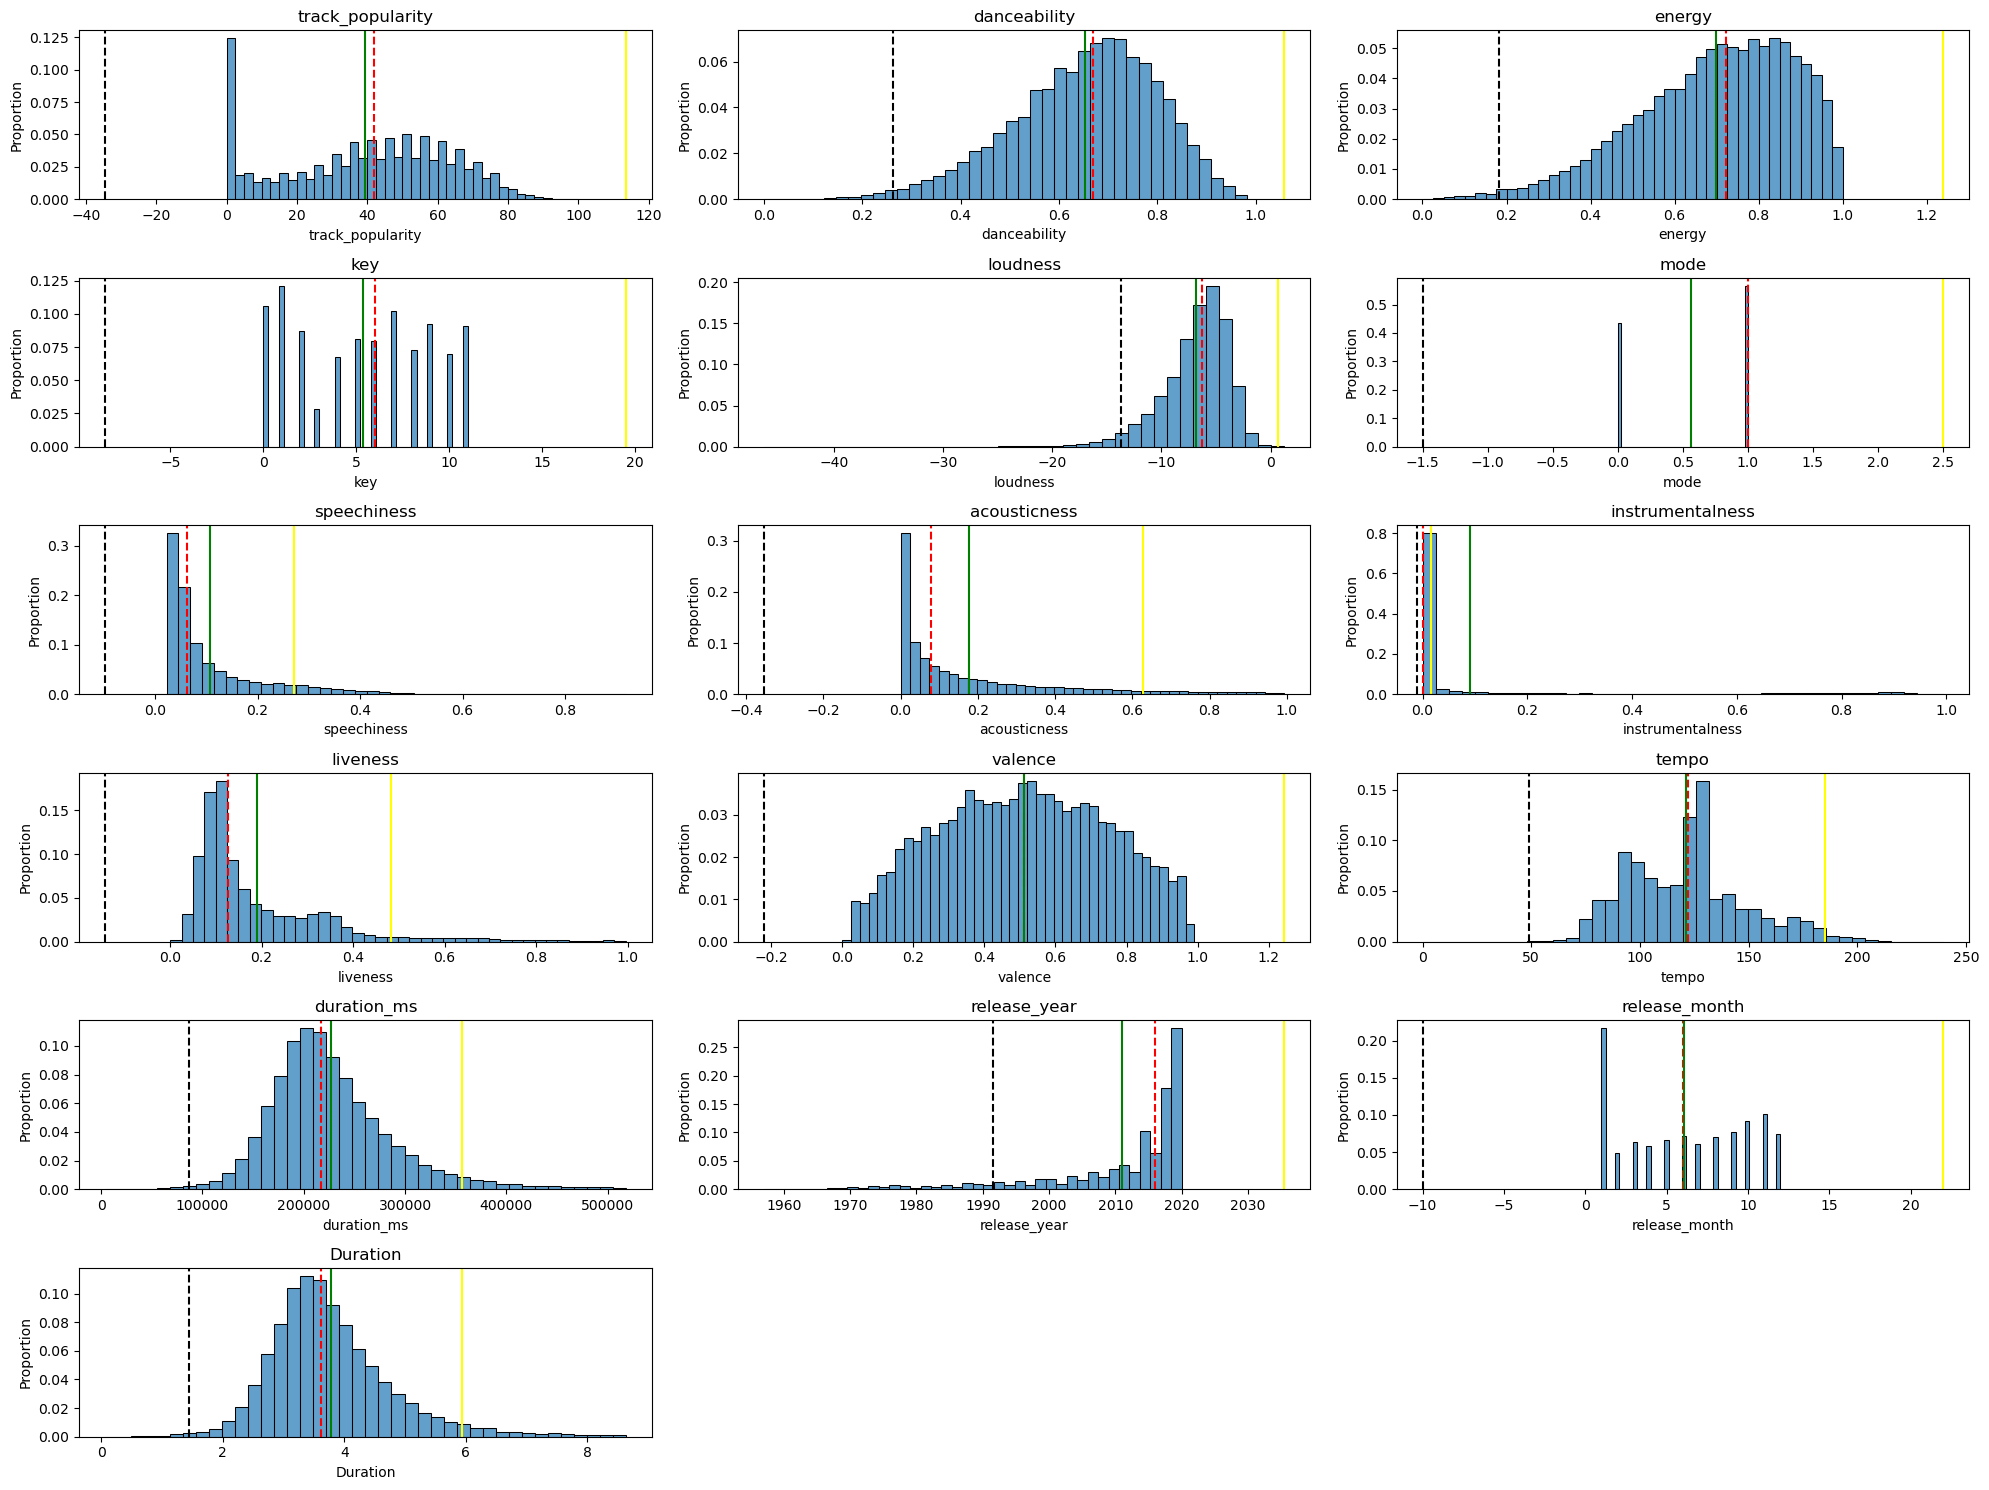

In [68]:

numeric_cols = data.select_dtypes(include='number').columns


plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    median= data[col].median()
    mean=data[col].mean()

    feature_q1 = data[col].quantile(0.25)
    feature_q3 = data[col].quantile(0.75)
    feature_iqr = feature_q3 - feature_q1
    l_bound = feature_q1 - 1.5* feature_iqr
    u_bound = feature_q3 + 1.5*feature_iqr

    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.histplot(data=data,x=col, bins=40, alpha=0.7,stat="proportion")
    plt.axvline(median, color='red', linestyle='--', label='Median')
    plt.axvline(mean, color='green', linestyle='-', label='Mean')
    plt.axvline(l_bound, color='black', linestyle='--', label='Lower Bound')
    plt.axvline(u_bound, color='yellow', linestyle='-', label='Upper Bound')


    plt.title(col)
plt.tight_layout()


plt.show()

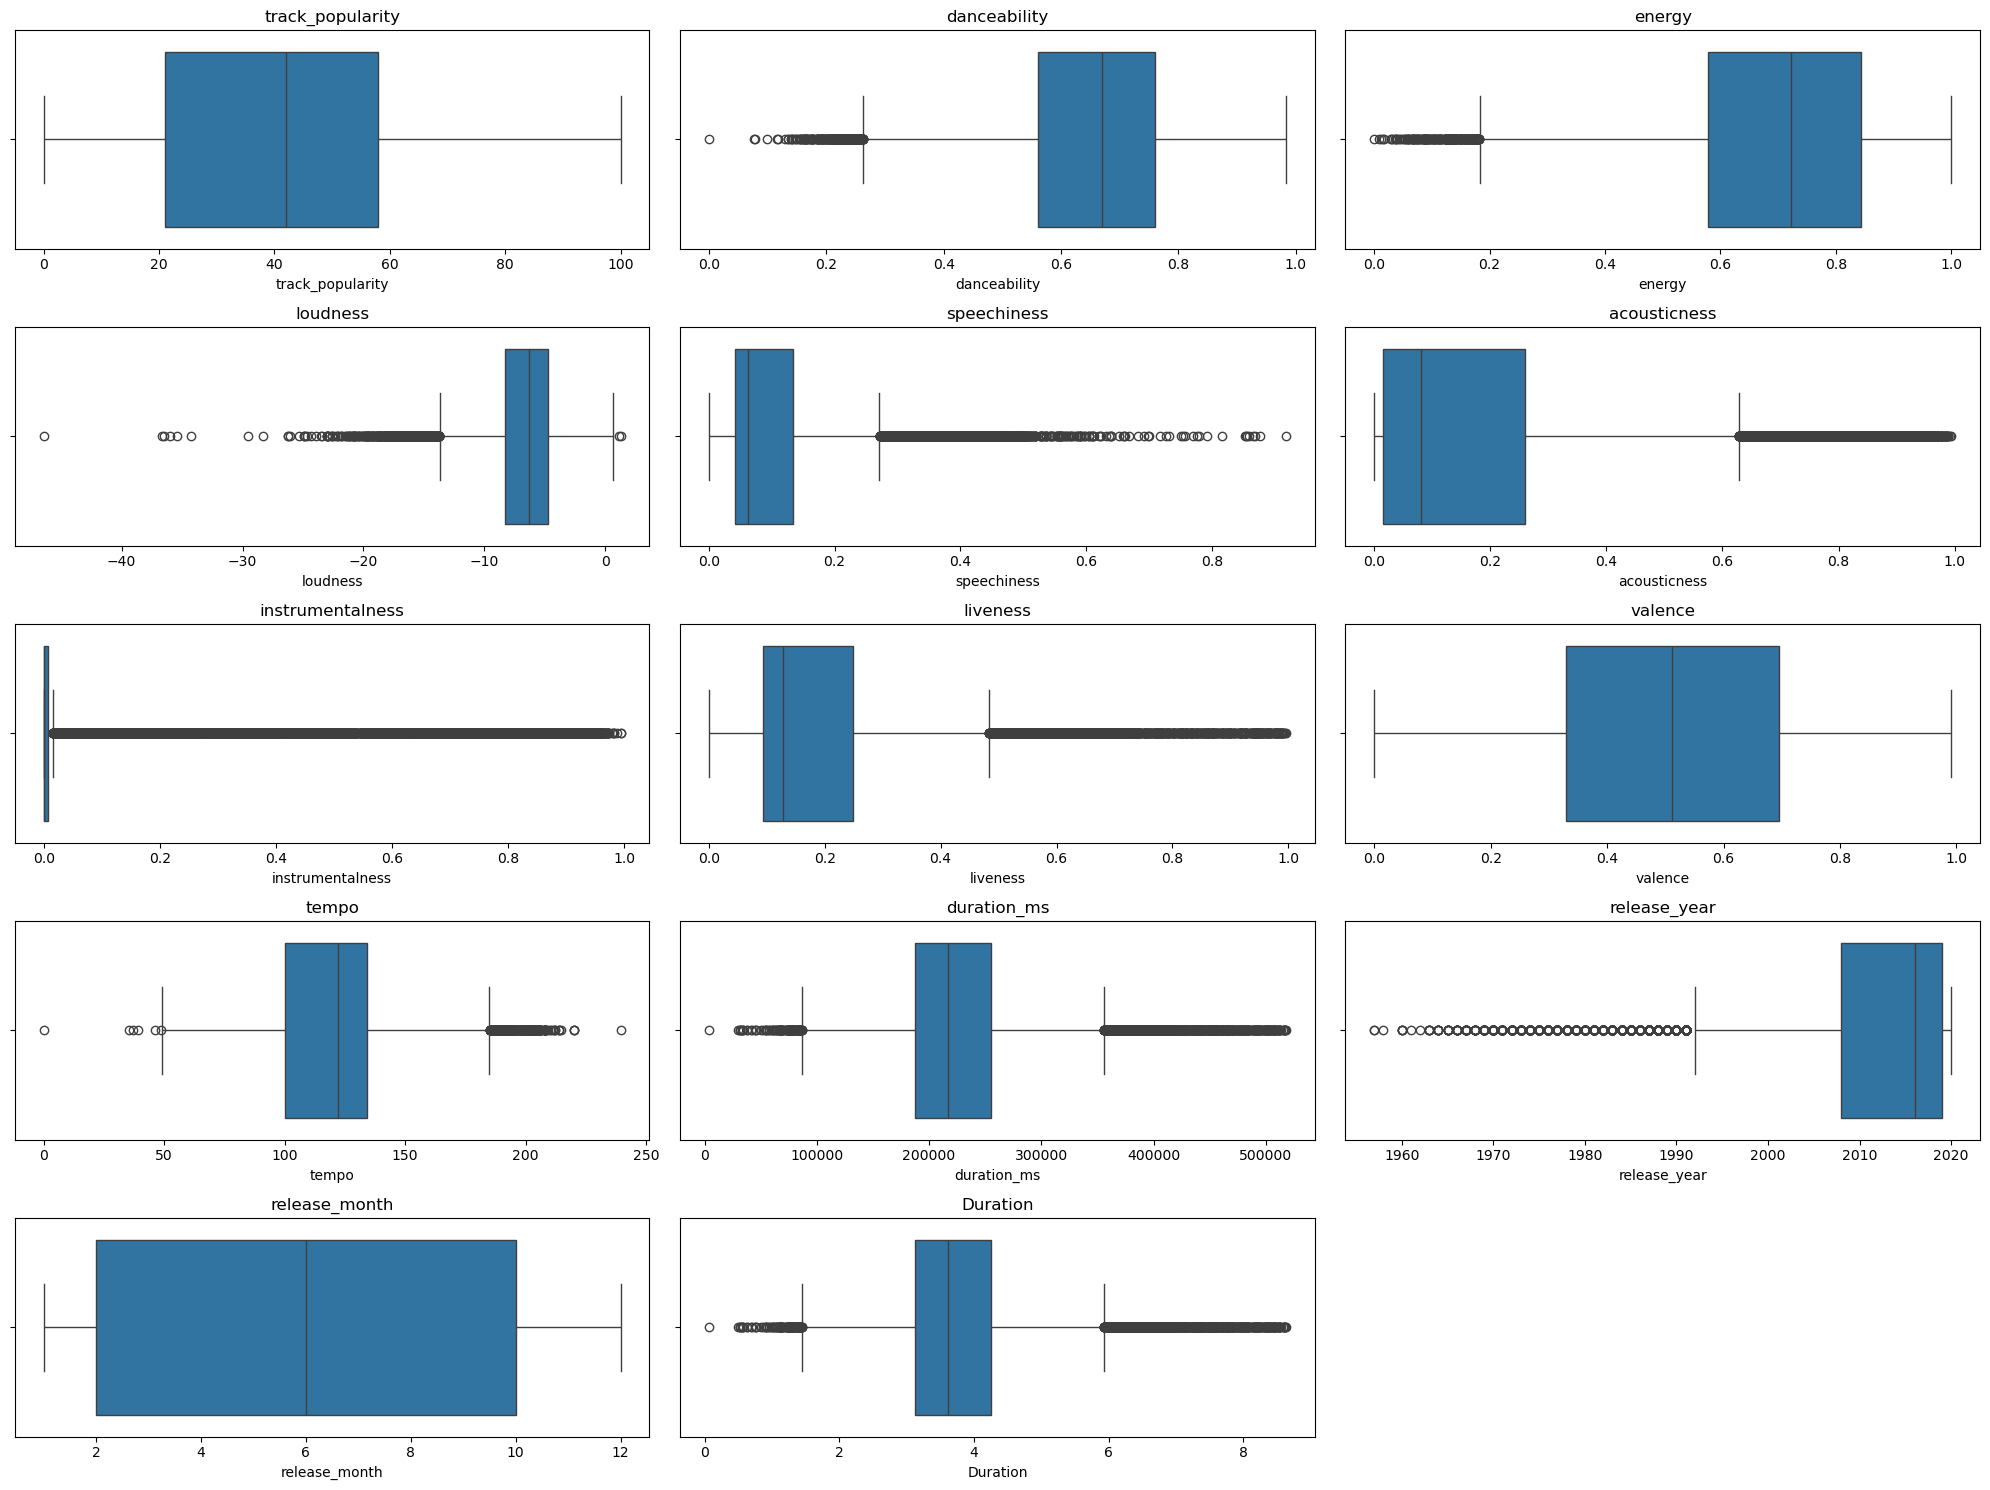

In [69]:

numeric_cols = data.select_dtypes(include='number').columns
numeric_cols=numeric_cols.drop('mode')
numeric_cols=numeric_cols.drop('key')


plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.boxplot(data=data, x=col,whis=1.5)
    plt.title(col)
plt.tight_layout()
plt.show()

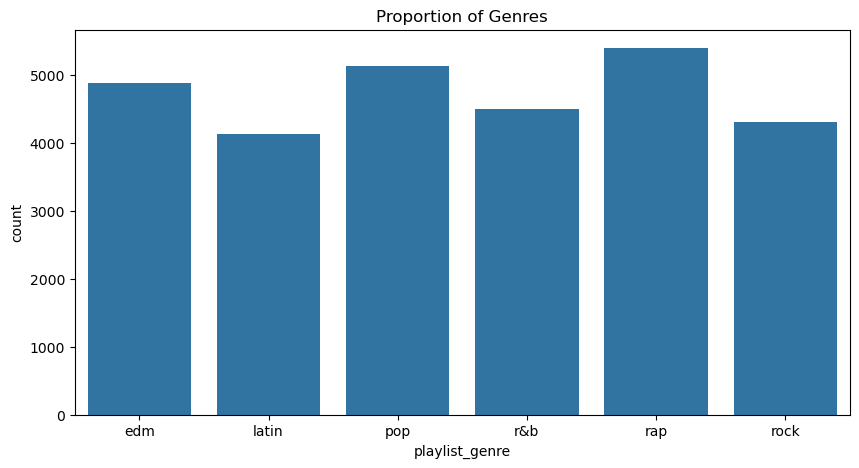

In [70]:

plt.figure(figsize=(10, 5))
sns.countplot(x='playlist_genre',data=data,)
plt.title("Proportion of Genres")
plt.show()

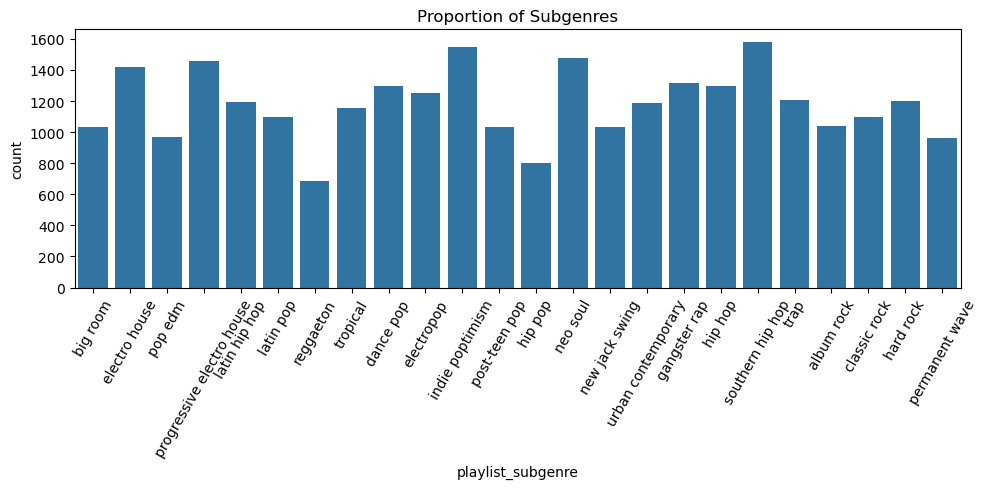

In [71]:

plt.figure(figsize=(10, 5))
sns.countplot(x='playlist_subgenre',data=data,)
plt.title("Proportion of Subgenres")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

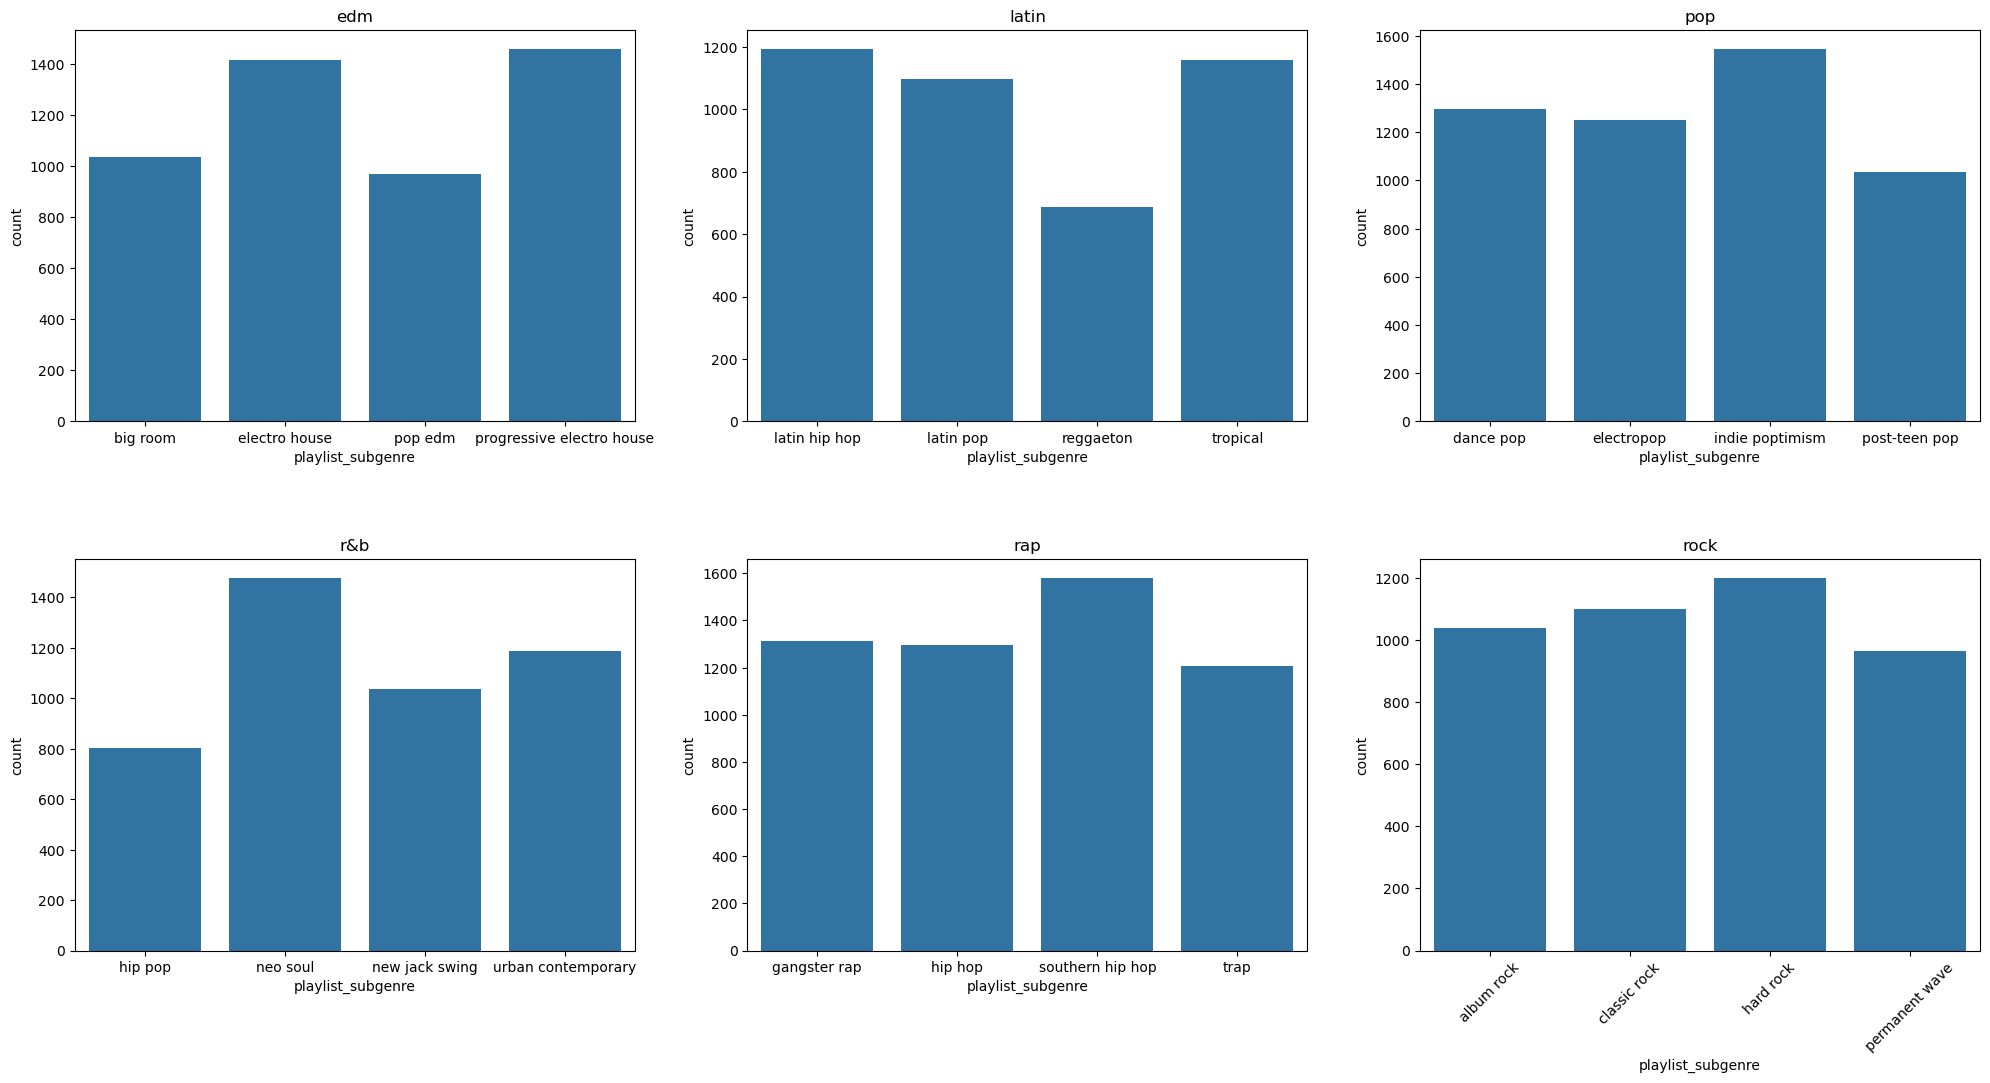

In [72]:
genre= data['playlist_genre'].unique()

plt.figure(figsize=(20, 15))
for i, col in enumerate(genre, 1):
    plt.subplot(len(genre)//3 + 1, 3, i)
    subgenre=data[data['playlist_genre']== col]
    sns.countplot(data=subgenre, x='playlist_subgenre',)
    plt.title(col)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

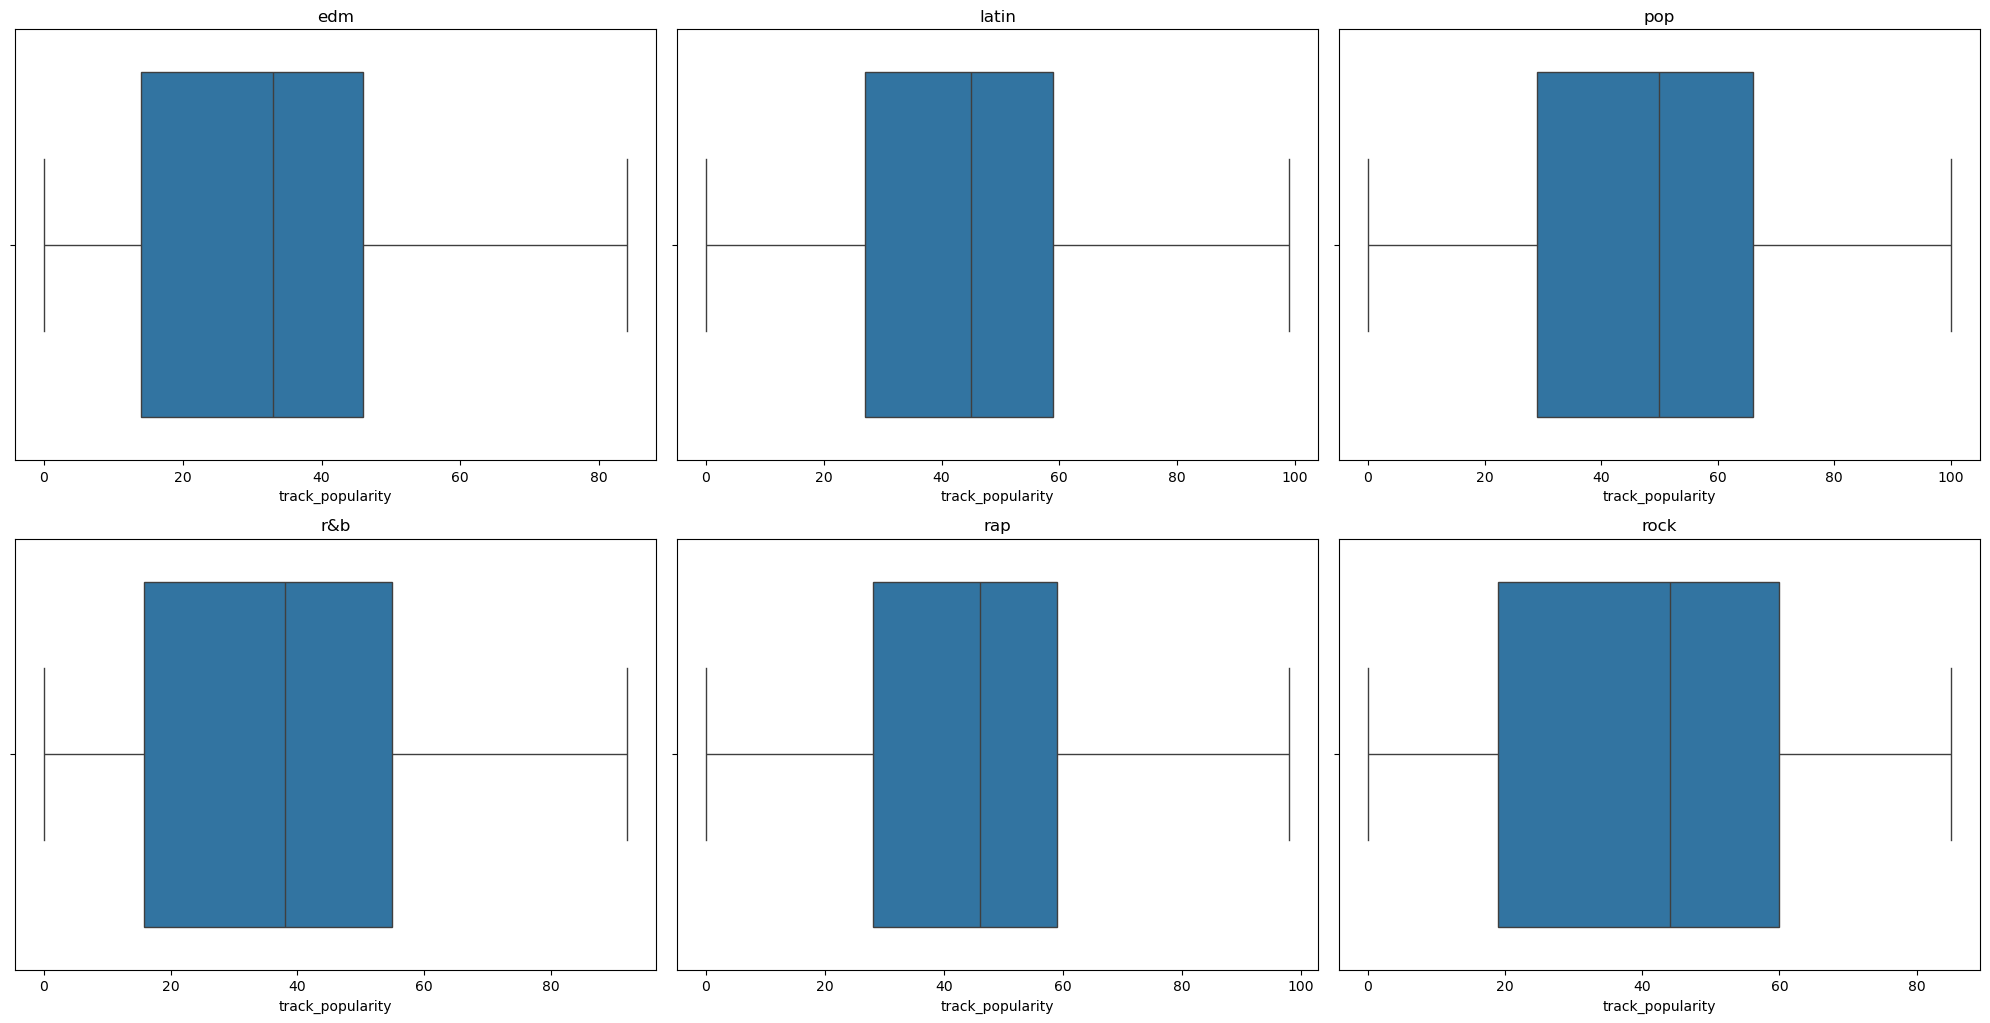

In [73]:

genre = data['playlist_genre'].unique()

plt.figure(figsize=(20, 15))
for i, col in enumerate(genre, 1):
    plt.subplot(len(genre)//3 + 1, 3, i)
    genre_data = data[data['playlist_genre'] == col]  # filter rows for this genre
    sns.boxplot(data=genre_data, x='track_popularity', whis=1.5)
    plt.title(col)
plt.tight_layout()
plt.show()

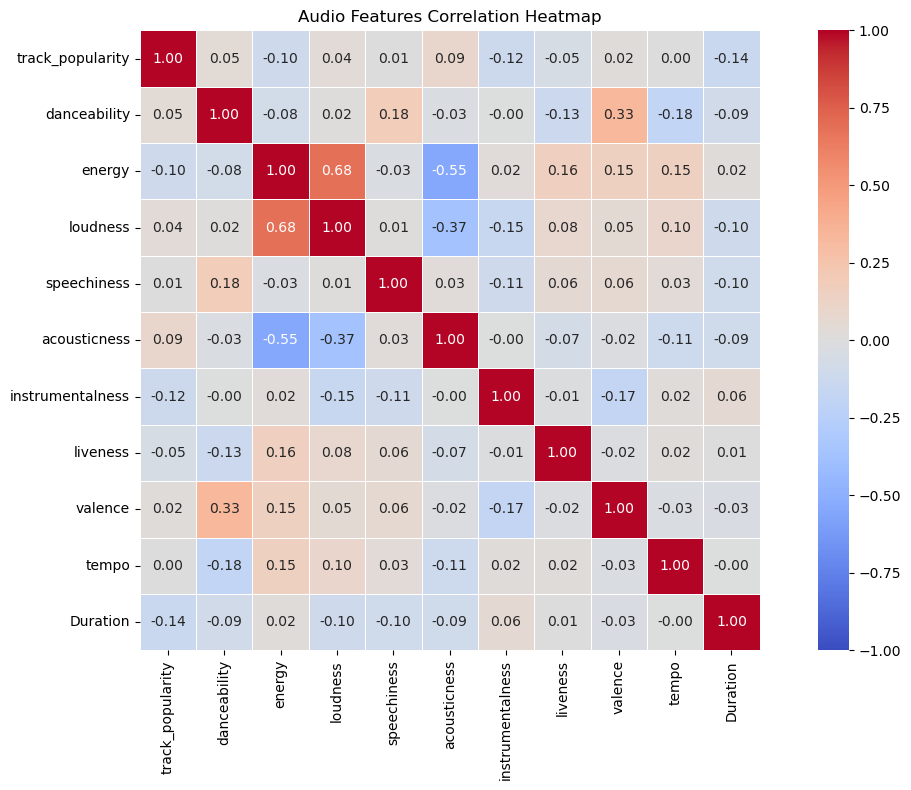

In [74]:
numeric_cols = ['track_popularity', 'danceability', 'energy', 'loudness', 
                'speechiness', 'acousticness', 'instrumentalness', 
                'liveness', 'valence', 'tempo', 'Duration']

corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values in each cell
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # red = positive, blue = negative
    center=0,            # center colorscale at 0
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Audio Features Correlation Heatmap')
plt.tight_layout()
plt.show()